# Warehouse

In [237]:
import sqlite3
import pandas as pd

target_db = 'GreatOutdoors/SDM.sqlite'
target_WH_db = 'GreatOutdoors/Warehouse.sqlite'
# Connections
sdm_conn = sqlite3.connect(target_db)
dwh_conn = sqlite3.connect(target_WH_db)



## Customer Headquarters

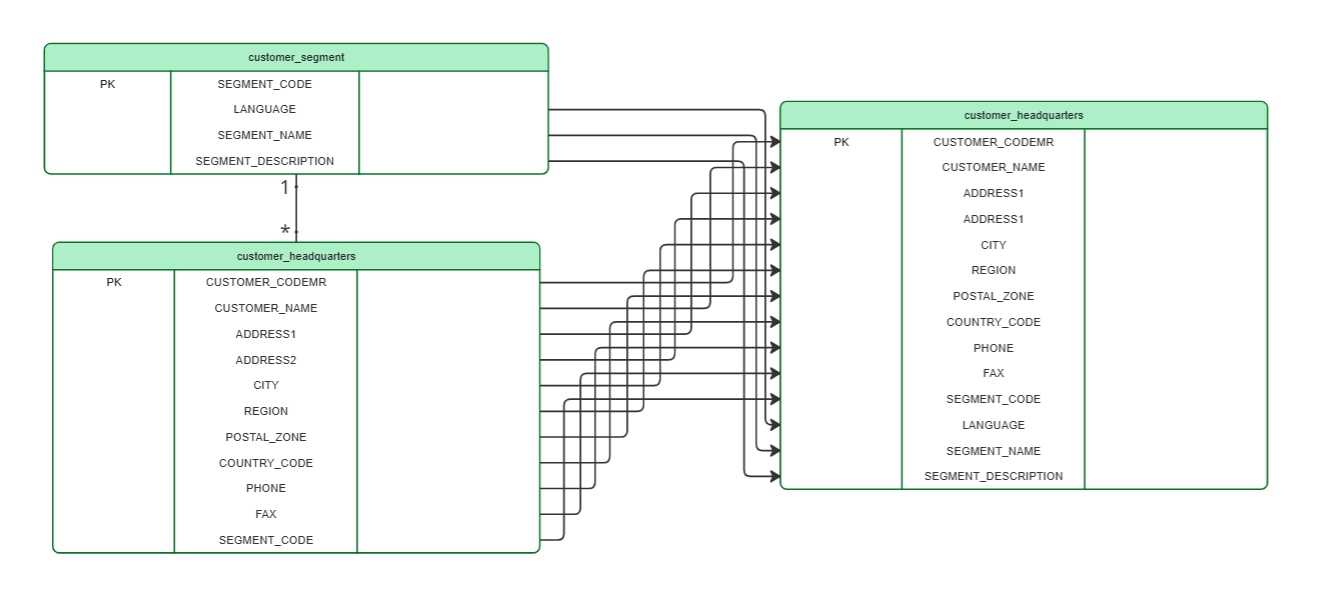

In [238]:
df_customer_segment            = pd.read_sql_query("SELECT * FROM Customer_Segment", sdm_conn)
df_customer_headquarters = pd.read_sql_query("SELECT * FROM Customer_Headquarters", sdm_conn)

df_customer_headquarters_final = pd.merge(
    df_customer_headquarters,
    df_customer_segment,
    left_on='SEGMENT_CODE',
    right_on='SEGMENT_CODE',
    how='left')
df_customer_headquarters_final = df_customer_headquarters_final[[
    'CUSTOMER_CODEMR',
    'CUSTOMER_NAME',
    'ADDRESS1',
    'ADDRESS2',
    'CITY',
    'REGION',
    'POSTAL_ZONE',
    'COUNTRY_CODE',
    'PHONE',
    'FAX',
    'SEGMENT_CODE',
    'LANGUAGE',
    'SEGMENT_NAME',
    'SEGMENT_DESCRIPTION'
]]

df_customer_headquarters_final

,CUSTOMER_CODEMR,CUSTOMER_NAME,ADDRESS1,ADDRESS2,CITY,REGION,POSTAL_ZONE,COUNTRY_CODE,PHONE,FAX,SEGMENT_CODE,LANGUAGE,SEGMENT_NAME,SEGMENT_DESCRIPTION
0,442,Morro Sports,"Rua Texeira de Freitas, 1248",6 Andar,Rio de Janeiro,RJ,20031-050,21,+55 (21) 224-7999,+55 (21) 224-0986,12,EN,Sports Store,Primarily offers a wide range of sporting goods.
1,454,"Hangzhou Superman Sports Goods Co., LTD.",59 Yang Fang Dian West,Hai Dian District,Beijing,NaN,100038,14,86-10-6252-8387,86-10-6252-8387,3,EN,Golf Shop,Primarily offers golf equipment and accessories.
2,455,"Lan King Sports Co., LTD.",No.339 Huan Shi Dong Road,NaN,Guangzhou,GuangDong,510098,14,86-20-8331-3501,86-20-8331-3501,1,EN,Outdoors Shop - Exclusive,"Primarily offers camping supplies, hiking equi..."
3,456,"China Multi-channel Sports Co., LTD.",No.318 Huan Cheng Bei Road,NaN,Hangzhou,Zhejiang,310012,14,86-571-525-2443,86-571-525-2443,7,EN,Direct Marketing,Offers a wide range of goods through mail orde...
4,457,Great Dragon Group,No.88 Zhong Shan Road,NaN,Harbin,Helong,150049,14,86-451-277-6197,86-451-277-6196,10,EN,Eyewear Store,Primarily offers prescription and fashion eyew...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409,437,Esportes Grumari,"Alameda Santos, 9876",6o. Andar,São Paulo,SP,04571-010,21,+55 (11) 288-5032,+55 (11) 288-2345,5,EN,Department Store,Offers a wide range of goods.
410,438,Casa do Alpinista,"Rua Machado de Assis, 1987",2o. Andar,Porto Alegre,RS,55230-333,21,+55 (51) 333-4587,+55 (51) 333-7777,11,EN,Sports Store - Exclusive,Primarily offers a wide range of sporting good...
411,439,Mega Shop do Esporte,"Av. Presidente Wilson, 9999",10 Andar,Rio de Janeiro,RJ,20031-050,21,+55 (21) 332-5509,+55 (21) 332-9999,8,EN,Warehouse Store,Offers a wide range of goods in a large wareho...
412,440,Esportópolis,"Rua Estados Unidos, 998",Térreo,São Paulo,SP,05120-900,21,+55 (11) 878-2275,+55 (11) 878-2387,8,EN,Warehouse Store,Offers a wide range of goods in a large wareho...


In [239]:
import sqlite3
import pandas as pd

# Ensure target_WH_db is defined earlier in your script
dwh_conn = sqlite3.connect(target_WH_db)

try:
    # 1. Read DWH and normalize columns
    df_dwh = pd.read_sql("SELECT * FROM Customer_Headquarters", dwh_conn)
    df_dwh.columns = df_dwh.columns.str.lower()
    
    # 2. Normalize source columns
    src_df = df_customer_headquarters_final.copy()
    src_df.columns = src_df.columns.str.lower()

    # --- FIX: TYPE ALIGNMENT ---
    # Convert SDM strings to numeric. 'coerce' turns invalid strings into NaN.
    src_df['customer_codemr'] = pd.to_numeric(src_df['customer_codemr'], errors='coerce')
    
    # Drop rows that couldn't be converted to numbers (optional but recommended)
    src_df = src_df.dropna(subset=['customer_codemr'])
    
    # Cast to int to match the Warehouse Dtype (int64)
    src_df['customer_codemr'] = src_df['customer_codemr'].astype(int)
    # ---------------------------

    # 3. DETECT NEW ROWS
    new_rows = src_df[~src_df['customer_codemr'].isin(df_dwh['customer_codemr'])]

    # 4. DETECT CHANGES
    comparison = pd.merge(
        src_df, 
        df_dwh, 
        on='customer_codemr', 
        suffixes=('_src', '_dwh')
    )

    cols_to_check = [
        'customer_name', 'address1', 'address2', 'city', 'region', 
        'postal_zone', 'country_code', 'phone', 'fax', 'segment_code', 
        'language', 'segment_name', 'segment_description'
    ]

    # Vectorized comparison
    changed_mask = comparison[[f"{c}_src" for c in cols_to_check]].ne(
        comparison[[f"{c}_dwh" for c in cols_to_check]].values
    ).any(axis=1)

    changed_rows = comparison[changed_mask]

    # 5. THE LOAD
    if not new_rows.empty:
        new_rows.to_sql('Customer_Headquarters', dwh_conn, if_exists='append', index=False)
        print(f"✨ Inserted {len(new_rows)} new customer records.")

    if not changed_rows.empty:
        cursor = dwh_conn.cursor()
        
        update_data = []
        for _, row in changed_rows.iterrows():
            update_data.append((
                row['customer_name_src'], row['address1_src'], row['address2_src'], 
                row['city_src'], row['region_src'], row['postal_zone_src'], 
                row['country_code_src'], row['phone_src'], row['fax_src'], 
                row['segment_code_src'], row['language_src'], row['segment_name_src'], 
                row['segment_description_src'], row['customer_codemr']
            ))

        sql = """
            UPDATE Customer_Headquarters 
            SET customer_name = ?, address1 = ?, address2 = ?, city = ?, region = ?, 
                postal_zone = ?, country_code = ?, phone = ?, fax = ?, 
                segment_code = ?, language = ?, segment_name = ?, segment_description = ?
            WHERE customer_codemr = ?
        """
        cursor.executemany(sql, update_data)
        dwh_conn.commit()
        print(f"🔄 Updated {len(changed_rows)} existing rows.")
    else:
        print("ℹ️ No changes detected.")

except Exception as e:
    print(f"❌ An error occurred: {e}")

finally:
    dwh_conn.close()
    print("🔌 Connection closed safely.")

🔄 Updated 414 existing rows.
🔌 Connection closed safely.


## Sales Demographic

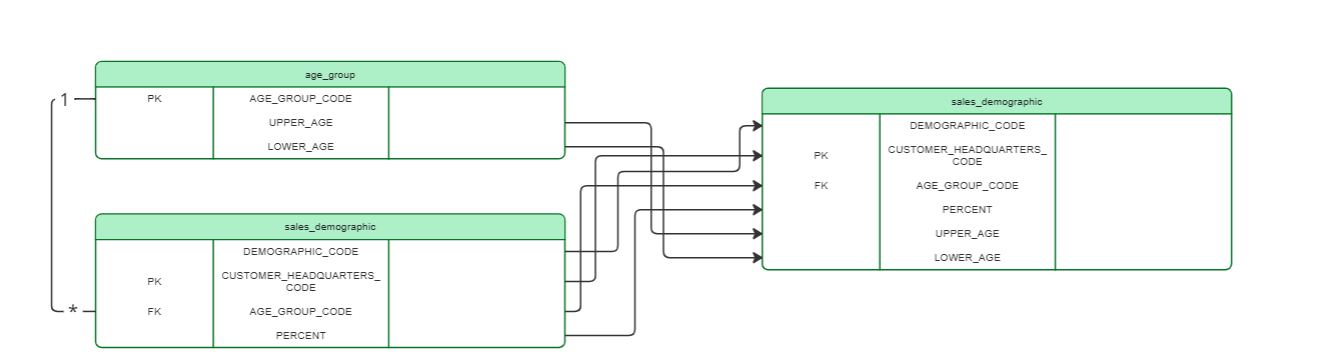

In [240]:
df_age_group            = pd.read_sql_query("SELECT * FROM Age_Group", sdm_conn)
df_sales_demographic = pd.read_sql_query("SELECT * FROM Sales_Demographic", sdm_conn)

df_sales_demographic_final = pd.merge(
    df_sales_demographic,
    df_age_group,
    left_on='AGE_GROUP_CODE',
    right_on='AGE_GROUP_CODE',
    how='left')
df_sales_demographic_final = df_sales_demographic_final[[
    'DEMOGRAPHIC_CODE',
    'CUSTOMER_CODEMR',
    'SALES_PERCENT',
    'LOWER_AGE',
    'UPPER_AGE'
]]

df_sales_demographic_final

,DEMOGRAPHIC_CODE,CUSTOMER_CODEMR,SALES_PERCENT,LOWER_AGE,UPPER_AGE
0,2475,405,25,41,50
1,2476,405,23,51,60
2,2477,405,24,61,70
3,2478,412,2,0,20
4,2479,412,4,21,30
...,...,...,...,...,...
2479,2470,627,10,51,60
2480,2471,627,0,61,70
2481,2472,405,0,0,20
2482,2473,405,6,21,30


In [241]:
import sqlite3
import pandas as pd

# Ensure target_WH_db is defined earlier in your script
dwh_conn = sqlite3.connect(target_WH_db)

try:
    # 1. Read DWH and normalize columns
    df_dwh = pd.read_sql("SELECT * FROM Sales_Demographic", dwh_conn)
    df_dwh.columns = df_dwh.columns.str.lower()
    
    # Normalize source columns
    src_df = df_sales_demographic_final.copy()
    src_df.columns = src_df.columns.str.lower()

    # --- FIX: TYPE ALIGNMENT ---
    # Convert SDM strings to numeric to match Warehouse INT
    src_df['demographic_code'] = pd.to_numeric(src_df['demographic_code'], errors='coerce')
    
    # Drop rows that couldn't be converted to numbers and cast to int
    src_df = src_df.dropna(subset=['demographic_code'])
    src_df['demographic_code'] = src_df['demographic_code'].astype(int)
    # ---------------------------

    # 2. DETECT NEW ROWS
    new_rows = src_df[~src_df['demographic_code'].isin(df_dwh['demographic_code'])]

    # 3. DETECT CHANGES
    comparison = pd.merge(
        src_df, 
        df_dwh, 
        on='demographic_code', 
        suffixes=('_src', '_dwh')
    )

    # Columns to check for changes
    cols_to_check = ['customer_codemr', 'sales_percent', 'upper_age', 'lower_age']

    # Vectorized comparison (Checks all columns at once)
    changed_mask = comparison[[f"{c}_src" for c in cols_to_check]].ne(
        comparison[[f"{c}_dwh" for c in cols_to_check]].values
    ).any(axis=1)

    changed_rows = comparison[changed_mask]

    # 4. THE LOAD
    if not new_rows.empty:
        new_rows.to_sql('Sales_Demographic', dwh_conn, if_exists='append', index=False)
        print(f"✨ Inserted {len(new_rows)} new sales_demographic records.")

    if not changed_rows.empty:
        cursor = dwh_conn.cursor()
        
        # Prepare batch update data
        update_data = []
        for _, row in changed_rows.iterrows():
            update_data.append((
                row['customer_codemr_src'], 
                row['sales_percent_src'], 
                row['upper_age_src'], 
                row['lower_age_src'], 
                row['demographic_code']
            ))

        sql = """
            UPDATE Sales_Demographic 
            SET customer_codemr = ?, sales_percent = ?, upper_age = ?, lower_age = ?
            WHERE demographic_code = ?
        """
        cursor.executemany(sql, update_data)
        dwh_conn.commit()
        print(f"🔄 Updated {len(changed_rows)} existing rows (SCD Type 1).")
    else:
        print("ℹ️ No changes detected between SDM and DWH.")

except Exception as e:
    print(f"❌ An error occurred: {e}")

finally:
    dwh_conn.close()
    print("🔌 Connection closed safely.")

🔄 Updated 2484 existing rows (SCD Type 1).
🔌 Connection closed safely.


## Customer

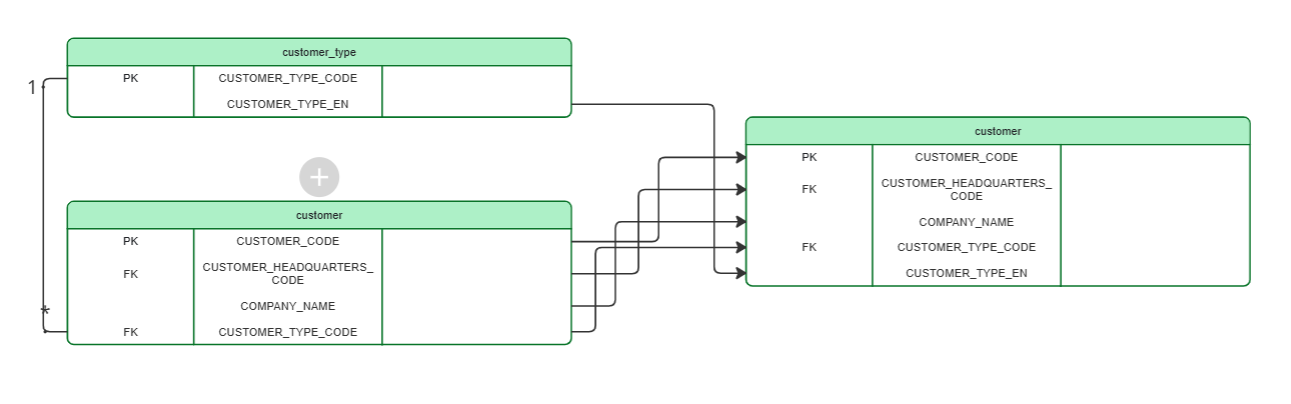

In [242]:
df_customer_type = pd.read_sql_query("SELECT * FROM Customer_Type", sdm_conn)
df_customer = pd.read_sql_query("SELECT * FROM Customer", sdm_conn)

df_customer_final = pd.merge(
    df_customer,
    df_customer_type,
    left_on='CUSTOMER_TYPE_CODE',
    right_on='CUSTOMER_TYPE_CODE',
    how='left')
df_customer_final = df_customer_final[[
    'CUSTOMER_CODE',
    'CUSTOMER_CODEMR',
    'COMPANY_NAME',
    'CUSTOMER_TYPE_EN'
]]

df_customer_final

,CUSTOMER_CODE,CUSTOMER_CODEMR,COMPANY_NAME,CUSTOMER_TYPE_EN
0,1,NaN,ActiForme,Equipment Rental Store
1,15,234,SportsClub,Golf Shop
2,23,229,Anapurna,Direct Marketing
3,32,230,Cordages Discount,Warehouse Store
4,33,228,Altitudes extrêmes,Outdoors Shop
...,...,...,...,...
104,193,428,Allo Allo,Direct Marketing
105,194,429,Caravanserai,Outdoors Shop
106,209,415,Ausrüstungshaus Globetrotter,Department Store
107,210,NaN,Golfer-Paradies,Golf Shop


In [243]:
import sqlite3
import pandas as pd

dwh_conn = sqlite3.connect(target_WH_db)

try:
    # 1. Read DWH and normalize
    df_dwh = pd.read_sql("SELECT * FROM Customer", dwh_conn)
    df_dwh.columns = df_dwh.columns.str.lower()
    
    # Normalize source columns
    src_df = df_customer_final.copy()
    src_df.columns = src_df.columns.str.lower()

    # FIX: TYPE ALIGNMENT (Source String -> DWH Integer)
    src_df['customer_code'] = pd.to_numeric(src_df['customer_code'], errors='coerce')
    src_df = src_df.dropna(subset=['customer_code'])
    src_df['customer_code'] = src_df['customer_code'].astype(int)

    # --- THE KEY FIX: ONLY KEEP COLUMNS THAT EXIST IN THE DWH ---
    # This prevents the "no column named..." error
    dwh_column_names = df_dwh.columns.tolist()
    src_df = src_df[[col for col in src_df.columns if col in dwh_column_names]]

    # 2. DETECT NEW ROWS
    new_rows = src_df[~src_df['customer_code'].isin(df_dwh['customer_code'])]

    # 3. DETECT CHANGES
    comparison = pd.merge(
        src_df, 
        df_dwh, 
        on='customer_code', 
        suffixes=('_src', '_dwh')
    )

    # Specify columns to check for updates (ensure these exist in your DB!)
    cols_to_check = ['customer_codemr', 'company_name', 'customer_type_en']
    
    # Filter list to only check columns that are actually present
    cols_to_check = [c for c in cols_to_check if c in src_df.columns]

    changed_mask = comparison[[f"{c}_src" for c in cols_to_check]].ne(
        comparison[[f"{c}_dwh" for c in cols_to_check]].values
    ).any(axis=1)

    changed_rows = comparison[changed_mask]

    # 4. THE LOAD
    if not new_rows.empty:
        # new_rows now only contains columns that the DWH actually has
        new_rows.to_sql('Customer', dwh_conn, if_exists='append', index=False)
        print(f"✨ Inserted {len(new_rows)} new customer records.")

    if not changed_rows.empty:
        cursor = dwh_conn.cursor()
        
        update_data = []
        for _, row in changed_rows.iterrows():
            update_data.append((
                row['customer_codemr_src'], 
                row['company_name_src'], 
                row['customer_type_en_src'], 
                row['customer_code']
            ))

        sql = """
            UPDATE Customer 
            SET customer_codemr = ?, company_name = ?, customer_type_en = ?
            WHERE customer_code = ?
        """
        cursor.executemany(sql, update_data)
        dwh_conn.commit()
        print(f"🔄 Updated {len(changed_rows)} existing records.")
    else:
        print("ℹ️ No changes detected.")

except Exception as e:
    print(f"❌ An error occurred: {e}")

finally:
    dwh_conn.close()
    print("🔌 Connection closed safely.")

ℹ️ No changes detected.
🔌 Connection closed safely.


## Customer Store

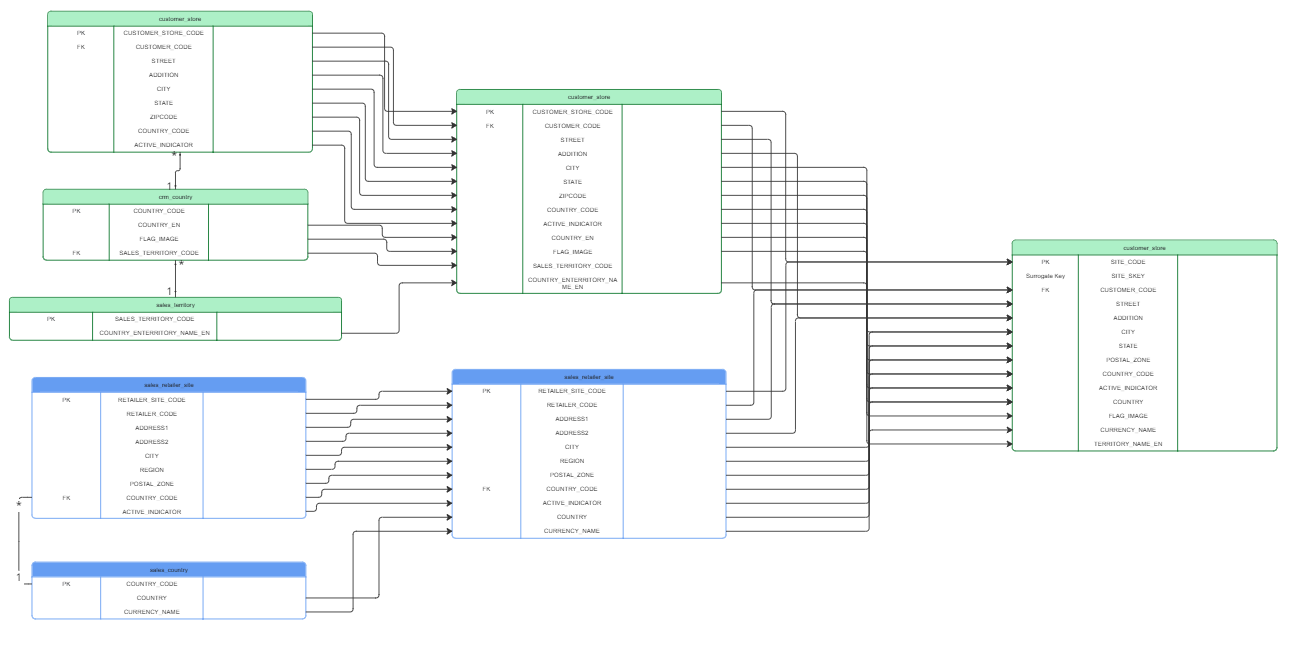

In [244]:
## Customer Store Part

df_customer_store = pd.read_sql_query("SELECT * FROM Customer_Store", sdm_conn)
df_crm_country = pd.read_sql_query("SELECT * FROM CRM_Country", sdm_conn)
df_sales_territory = pd.read_sql_query("SELECT * FROM Sales_Territory", sdm_conn)

df_crm_country_final = pd.merge(
    df_crm_country,
    df_sales_territory,
    left_on='SALES_TERRITORY_CODE',
    right_on='SALES_TERRITORY_CODE',
    how='left')

df_customer_store_final = pd.merge(
    df_customer_store,
    df_crm_country_final,
    left_on='COUNTRY_CODE',
    right_on='COUNTRY_CODE',
    how='left')

#Fix the column names
# Both tables likely have a 'naam' column, so Pandas makes them 'naam_x' and 'naam_y'
df_customer_store_final = df_customer_store_final.rename(columns={
    'CUSTOMER_SITE_CODE': 'SITE_CODE',
    'ZIPCODE': 'POSTAL_ZONE',             # The accessory name
    'COUNTRY_EN': 'COUNTRY'  # The supplier name
})

df_customer_store_final = df_customer_store_final[[
    'SITE_CODE',
    'CUSTOMER_CODE',
    'STREET',
    'ADDITION',
    'CITY',
    'POSTAL_ZONE',
    'COUNTRY_CODE',
    'ACTIVE_INDICATOR',
    'COUNTRY',
    'FLAG_IMAGE',
    'TERRITORY_NAME_EN'
]]


## Retailer Site Part

df_retailer_site = pd.read_sql_query("SELECT * FROM Retailer_Site", sdm_conn)
df_country = pd.read_sql_query("SELECT * FROM Sales_Country", sdm_conn)

df_retailer_site_final = pd.merge(
    df_retailer_site,
    df_country,
    left_on='COUNTRY_CODE',
    right_on='COUNTRY_CODE',
    how='left')

#Fix the column names
# Both tables likely have a 'naam' column, so Pandas makes them 'naam_x' and 'naam_y'
df_retailer_site_final = df_retailer_site_final.rename(columns={
    'RETAILER_SITE_CODE': 'SITE_CODE',
    'RETAILER_CODE': 'CUSTOMER_CODE',
    'ADDRESS1': 'STREET',
    'ADDRESS2': 'ADDITION',             # The accessory name
    'REGION': 'STATE'  # The supplier name
})

df_retailer_site_final = df_retailer_site_final[[
    'SITE_CODE',
    'CUSTOMER_CODE',
    'STREET',
    'ADDITION',
    'CITY',
    'POSTAL_ZONE',
    'COUNTRY_CODE',
    'ACTIVE_INDICATOR',
    'COUNTRY',
    'CURRENCY_NAME'
]]


# 1. Identify columns in Customer that ARE NOT in Retailer
# We keep 'SITE_CODE' because we need it to join!
unique_customer_cols = [col for col in df_customer_store_final.columns 
                        if col not in df_retailer_site_final.columns or col == 'SITE_CODE']

# 2. Merge only with those specific columns
df_site_final = pd.merge(
    df_retailer_site_final,
    df_customer_store_final[unique_customer_cols],
    on='SITE_CODE',
    how='left'
)
df_site_final

,SITE_CODE,CUSTOMER_CODE,STREET,ADDITION,CITY,POSTAL_ZONE,COUNTRY_CODE,ACTIVE_INDICATOR,COUNTRY,CURRENCY_NAME,FLAG_IMAGE,TERRITORY_NAME_EN
0,1,89,1117 Franklin Blvd,NaN,Winnipeg,R2C 0M5,4,1,Canada,dollars,F04,Americas
1,2,89,"45, rue Atwater",NaN,Montréal,H2T 9K8,4,1,Canada,dollars,F04,Americas
2,3,89,328 Hodgson Road,NaN,Fredericton,E3B 2H2,4,1,Canada,dollars,F04,Americas
3,4,90,"2425, rue Peel",NaN,Montréal,H4G 3T4,4,1,Canada,dollars,F04,Americas
4,5,90,34 8th Avenue,NaN,Sudbury,M5V 1G5,4,1,Canada,dollars,F04,Americas
...,...,...,...,...,...,...,...,...,...,...,...,...
386,439,209,Hüttenstraße 87,NaN,Klosterneuburg,A-3400,5,1,Austria,schillings,F05,Southern Europe
387,440,209,Hauptstraße 85,NaN,Linz,A-4015,5,1,Austria,schillings,F05,Southern Europe
388,441,209,Amselweg 8,NaN,Innsbruck,A-6020,5,1,Austria,schillings,F05,Southern Europe
389,442,209,Hasengasse 38,NaN,Ischgl,A-6561,5,1,Austria,schillings,F05,Southern Europe


In [245]:
import sqlite3
import pandas as pd
from datetime import datetime

# Settings
today = datetime.now().strftime('%Y-%m-%d')

def run_scd2_site(df_source, db_path):
    conn = sqlite3.connect(db_path)
    
    try:
        df_dwh = pd.read_sql("SELECT * FROM Site WHERE is_current = 1", conn)
        df_dwh.columns = df_dwh.columns.str.lower()
        
        # Ensure site_code types match exactly
        df_dwh['site_code'] = pd.to_numeric(df_dwh['site_code'], errors='coerce').fillna(0).astype(int)
        df_source['site_code'] = pd.to_numeric(df_source['site_code'], errors='coerce').fillna(0).astype(int)
    except Exception as e:
        df_dwh = pd.DataFrame(columns=df_source.columns.str.lower())

    # 1. Identify NEW records
    df_new_site = df_source[~df_source['site_code'].isin(df_dwh['site_code'])].copy()

    # 2. Identify CHANGED records
    merged = pd.merge(df_source, df_dwh, on='site_code', suffixes=('_src', '_dwh'))
    
    # Only check columns existing in both (ignores site_skey, valid_to, etc.)
    common_cols = [c for c in df_source.columns if c in df_dwh.columns and c != 'site_code']
    
    change_mask = pd.Series([False] * len(merged))
    
    for col in common_cols:
        # Crucial fix: fillna('') converts float nan to empty string so they compare correctly
        src_val = merged[f'{col}_src'].fillna('').astype(str).replace(['nan', 'None', '<NA>'], '').str.strip()
        dwh_val = merged[f'{col}_dwh'].fillna('').astype(str).replace(['nan', 'None', '<NA>'], '').str.strip()
        
        change_mask |= (src_val != dwh_val)

    changed_ids = merged.loc[change_mask, 'site_code'].unique().tolist()

    cursor = conn.cursor()
    if changed_ids:
        for m_id in changed_ids:
            cursor.execute("""
                UPDATE Site 
                SET is_current = 0, valid_to = ? 
                WHERE site_code = ? AND is_current = 1
            """, (today, int(m_id)))
        conn.commit()

    df_updates = df_source[df_source['site_code'].isin(changed_ids)].copy()
    df_to_insert = pd.concat([df_new_site, df_updates], ignore_index=True)

    if not df_to_insert.empty:
        df_to_insert['is_current'] = 1
        df_to_insert['valid_from'] = today
        df_to_insert['valid_to'] = '9999-12-31'
        df_to_insert.to_sql('Site', conn, if_exists='append', index=False)
        print(f"🚀 {len(df_to_insert)} records processed (New: {len(df_new_site)}, Updates: {len(df_updates)}).")
    else:
        print("ℹ️ No changes detected.")
    conn.close()

# Run it
df_site_final.columns = df_site_final.columns.str.lower()
run_scd2_site(df_site_final, target_WH_db)

ℹ️ No changes detected.


## Customer Contact

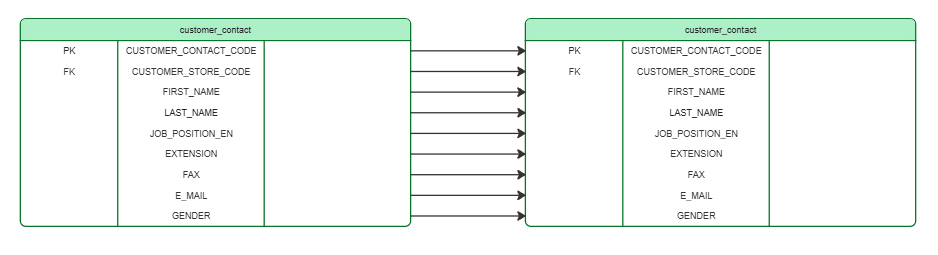

In [246]:
df_customer_contact = pd.read_sql_query("SELECT * FROM Customer_Contact", sdm_conn)

import sqlite3
import pandas as pd

# Ensure target_WH_db is defined earlier in your script
dwh_conn = sqlite3.connect(target_WH_db)

try:
    # 1. Read DWH and normalize columns
    df_dwh = pd.read_sql("SELECT * FROM Customer_Contact", dwh_conn)
    df_dwh.columns = df_dwh.columns.str.lower()
    
    # Normalize source columns
    src_df = df_customer_contact.copy()
    src_df.columns = src_df.columns.str.lower()

    # --- FIX: TYPE ALIGNMENT & TYPO ---
    # Convert SDM strings to numeric
    src_df['customer_contact_code'] = pd.to_numeric(src_df['customer_contact_code'], errors='coerce')
    
    # FIXED: Changed 'customer_contract_code' to 'customer_contact_code'
    src_df = src_df.dropna(subset=['customer_contact_code'])
    src_df['customer_contact_code'] = src_df['customer_contact_code'].astype(int)
    # ---------------------------

    # 2. DETECT NEW ROWS
    new_rows = src_df[~src_df['customer_contact_code'].isin(df_dwh['customer_contact_code'])]

    # 3. DETECT CHANGES
    comparison = pd.merge(
        src_df, 
        df_dwh, 
        on='customer_contact_code', 
        suffixes=('_src', '_dwh')
    )

    # Columns to check for changes
    cols_to_check = ['customer_site_code', 'first_name', 'last_name', 'job_position_en', 'extension', 'fax', 'e_mail', 'gender']

    # Vectorized comparison
    # We use .fillna('') and .astype(str) to prevent NaN != NaN false positives
    src_comp = comparison[[f"{c}_src" for c in cols_to_check]].fillna('').astype(str)
    dwh_comp = comparison[[f"{c}_dwh" for c in cols_to_check]].fillna('').astype(str)
    
    changed_mask = (src_comp.values != dwh_comp.values).any(axis=1)
    changed_rows = comparison[changed_mask]

    # 4. THE LOAD
    if not new_rows.empty:
        # Only keep the original columns for the insert
        cols_to_keep = [c.lower() for c in df_customer_contact.columns]
        new_rows_to_insert = new_rows[cols_to_keep]
        new_rows_to_insert.to_sql('Customer_Contact', dwh_conn, if_exists='append', index=False)
        print(f"✨ Inserted {len(new_rows)} new customer_contact records.")

    if not changed_rows.empty:
        cursor = dwh_conn.cursor()
        
        # Prepare batch update data
        update_data = []
        for _, row in changed_rows.iterrows():
            update_data.append((
                row['customer_site_code_src'], 
                row['first_name_src'], 
                row['last_name_src'], 
                row['job_position_en_src'], 
                row['extension_src'],
                row['fax_src'],
                row['e_mail_src'],
                row['gender_src'],
                int(row['customer_contact_code']) # The ID for the WHERE clause
            ))

        sql = """
            UPDATE Customer_Contact 
            SET customer_site_code = ?, first_name = ?, last_name = ?, job_position_en = ?, extension = ?, fax = ?, e_mail = ?, gender = ?
            WHERE customer_contact_code = ?
        """
        cursor.executemany(sql, update_data)
        dwh_conn.commit()
        print(f"🔄 Updated {len(changed_rows)} existing rows (SCD Type 1).")
    
    if new_rows.empty and changed_rows.empty:
        print("ℹ️ No changes detected between SDM and DWH.")

except Exception as e:
    print(f"❌ An error occurred: {e}")

finally:
    dwh_conn.close()
    print("🔌 Connection closed safely.")

ℹ️ No changes detected between SDM and DWH.
🔌 Connection closed safely.
